# Considering constraints and multiple objectives 
### Task
In this assignment, you must develop one NSGA and one SPEA variant to solve the capacitated p-median problem. In your case, you will solve a multi-objective version, where you need to place p facilities (medians) to (a) minimize service distance while (b) maximizing facility dispersion.
### Data
The file contains 18 instances formatted as follows:
- first line: instance ID, and best known solution (this means you may find a better one)
- second line: number of customers, number of medians, capacity of each median
- remaining lines: customer ID, x coordinate, y coordinate, demand


### Solution Representation
An array of length p containing the unique integer IDs of the chosen facility locations.

In [68]:
# imports
import math
import random
import matplotlib.pyplot as plt
import itertools

### Parsing the data

In [69]:
class PMedianInstance:
    def __init__(self):
        self.id = 0
        self.best_known = 0
        self.n = 0 # Number of customers
        self.p = 0 # Number of facilities to open
        self.capacity = 0 # Maximum demand a facility can serve
        self.customers = [] # List to hold customer data
        self.distance_matrix = [] # 2D array for pre-calculated distances

    def calculate_distance_matrix(self):
        """Pre-calculates the Euclidean distance between all pairs of nodes."""
        self.distance_matrix = [[0.0 for _ in range(self.n)] for _ in range(self.n)]
        for i in range(self.n):
            for j in range(self.n):
                if i != j:
                    dx = self.customers[i]['x'] - self.customers[j]['x']
                    dy = self.customers[i]['y'] - self.customers[j]['y']
                    # Standard Euclidean distance
                    self.distance_matrix[i][j] = math.sqrt(dx**2 + dy**2)

In [70]:
def parse_p_median_data(file_content):
    """
    Parses the text content of the p-median instances.
    Assumes file_content is a list of lines or a single string with newlines.
    """
    instances = []
    
    # If a single string is passed, split it into lines
    if isinstance(file_content, str):
        lines = file_content.strip().split('\n')
    else:
        lines = file_content
        
    # Clean up any potential formatting artifacts like '' if reading directly from your raw text
    clean_lines = []
    for line in lines:
        cleaned = line.split(']')[-1].strip() # Removes '' tags if present
        if cleaned:
             clean_lines.append(cleaned)

    i = 0
    while i < len(clean_lines):
        # 1. Parse Instance Header (ID and Best Known)
        parts = clean_lines[i].split()
        if len(parts) < 2: 
            i += 1
            continue
            
        instance = PMedianInstance()
        instance.id = int(parts[0])
        instance.best_known = float(parts[1])
        
        # 2. Parse n, p, capacity
        # n = number of customers, p = number of facilities to open, capacity = max demand a facility can serve
        i += 1
        parts = clean_lines[i].split()
        instance.n = int(parts[0])
        instance.p = int(parts[1])
        instance.capacity = float(parts[2])
        
        # 3. Parse customer locations and demands
        for _ in range(instance.n):
            i += 1
            parts = clean_lines[i].split()
            customer = {
                'id': int(parts[0]),     # 1-indexed ID as per the file
                'x': float(parts[1]),
                'y': float(parts[2]),
                'demand': float(parts[3])
            }
            instance.customers.append(customer)
            
        # Pre-calculate distances for this instance
        instance.calculate_distance_matrix()
        instances.append(instance)
        
        i += 1 # Move to the next instance

    return instances

In [71]:
filename = "p_median_capacitated.txt"
with open(filename, 'r') as file:
    data = file.read()
    
parsed_instances = parse_p_median_data(data)
print(f"Parsed {len(parsed_instances)} instances.")
print(f"Instance 1 requires {parsed_instances[0].p} facilities.")

Parsed 18 instances.
Instance 1 requires 5 facilities.


### Fitness Function

In [72]:
def evaluate_fitness(chromosome, instance):
    """
    Evaluates a chromosome (list of chosen facility indices).
    Returns a tuple: (service_distance, negative_dispersion)
    Both should be minimized by the MOEA.
    """
    # --- 1. Calculate Facility Dispersion ---
    min_dispersion = float('inf')
    for i in range(len(chromosome)):
        for j in range(i + 1, len(chromosome)):
            dist = instance.distance_matrix[chromosome[i]][chromosome[j]]
            if dist < min_dispersion:
                min_dispersion = dist
                
    # To maximize dispersion in a minimizing MOEA, we make it negative (inverse the maximization objective to minimization)
    dispersion_score = -min_dispersion 

    # --- 2. Calculate Service Distance & Allocation ---
    total_service_distance = 0.0
    
    # Track remaining capacity for the chosen facilities
    # Dictionary mapping facility index to its remaining capacity
    remaining_capacity = {fac_idx: instance.capacity for fac_idx in chromosome}
    
    # Sort customers by demand (descending) to pack the "heaviest" ones first
    sorted_customers = sorted(
        range(instance.n), 
        key=lambda idx: instance.customers[idx]['demand'], 
        reverse=True
    )
    
    penalty_multiplier = 10000 # Heavy penalty for unassigned demand

    for cust_idx in sorted_customers:
        cust_demand = instance.customers[cust_idx]['demand']
        
        # If the customer is ALSO a chosen facility, they serve themselves 
        # (distance is 0), but it still takes up capacity!
        if cust_idx in chromosome:
            best_facility = cust_idx
            best_distance = 0.0
        else:
            # Find the closest facility that has enough capacity
            best_facility = None
            best_distance = float('inf')
            
            for fac_idx in chromosome:
                if remaining_capacity[fac_idx] >= cust_demand:
                    dist = instance.distance_matrix[cust_idx][fac_idx]
                    if dist < best_distance:
                        best_distance = dist
                        best_facility = fac_idx
        
        # Assign customer or apply penalty
        if best_facility is not None:
            remaining_capacity[best_facility] -= cust_demand
            total_service_distance += best_distance
        else:
            # Constraint violation: No facility can take this customer
            total_service_distance += (cust_demand * penalty_multiplier)

    return (total_service_distance, dispersion_score)

# Example usage:
# chromosome = [0, 15, 22, 38, 49] # Note: Use 0-indexed customer IDs
# fitness = evaluate_fitness(chromosome, parsed_instances[0])
# print(f"Distance: {fitness[0]}, Dispersion: {-fitness[1]}")

### Crossover

In [73]:
def crossover(parent1, parent2, p):
    """
    Set-based crossover for p-median representation.
    parent1, parent2: lists of p unique integer IDs.
    Returns a new child list of length p.
    """
    # Convert to sets for easy intersection and union
    set1 = set(parent1)
    set2 = set(parent2)
    
    # 1. Keep facilities that both parents agree on
    common_facilities = list(set1.intersection(set2))
    
    # 2. Pool the facilities that are unique to each parent
    unique_facilities = list(set1.symmetric_difference(set2))
    
    # 3. Calculate how many more facilities the child needs
    needed = p - len(common_facilities)
    
    # 4. Randomly select the remaining needed facilities from the unique pool
    # (Using random.sample ensures we don't pick duplicates)
    chosen_unique = random.sample(unique_facilities, needed)
    
    # Combine and return as a list
    child = common_facilities + chosen_unique
    return child

### Mutation

In [74]:
def mutate(chromosome, n, mutation_rate=0.1):
    """
    Replacement mutation for p-median representation.
    chromosome: list of p unique integer IDs.
    n: total number of available customer locations (0 to n-1).
    """
    # Only mutate based on the probability
    if random.random() > mutation_rate:
        return chromosome[:] # Return a copy of the original
        
    mutated = chromosome[:]
    
    # 1. Pick a random index in the chromosome to replace
    idx_to_replace = random.randint(0, len(mutated) - 1)
    
    # 2. Create a pool of all valid nodes that are NOT currently in the chromosome
    current_set = set(mutated)
    available_nodes = [i for i in range(n) if i not in current_set]
    
    # 3. Pick a new node and swap it in
    new_node = random.choice(available_nodes)
    mutated[idx_to_replace] = new_node
    
    return mutated

# Example usage:
# parent_a = [12, 4, 38, 41, 19]
# parent_b = [12, 4, 9, 22, 19] # Shares 12, 4, and 19 with parent_a
# child = crossover(parent_a, parent_b, p=5)
# mutated_child = mutate(child, n=50, mutation_rate=1.0) # Forced mutation for testing
# print(f"mutated_child: {mutated_child}")

### Non dominant sorting genetic algorithm (NSGA)
Recap: Solution A is said to dominate Solution B if two conditions are met:
- Solution A is no worse than Solution B in all objectives.
- Solution A is strictly better than Solution B in at least one objective.

Non dominated sorting:
NSGA II evalutes entire population and sort them into fronts
- Front 1: Best solutions. No solution dominates them
- Front 2: Second best solutions. Only dominated by Front 1.
- Front 3: Thrid best solutions. Only dominated by Front 1 & 2.
- ... 

In [75]:
def dominates(fitness_a, fitness_b):
    """
    Checks if solution A dominates solution B.
    Assumes both objectives in the fitness tuple are to be MINIMIZED.
    fitness_a: (distance_A, negative_dispersion_A)
    """
    # A is no worse than B in all objectives
    no_worse = (fitness_a[0] <= fitness_b[0]) and (fitness_a[1] <= fitness_b[1])
    # A is strictly better than B in at least one objective
    strictly_better = (fitness_a[0] < fitness_b[0]) or (fitness_a[1] < fitness_b[1])
    
    return no_worse and strictly_better

def fast_non_dominated_sort(population_fitnesses):
    """
    Sorts a population into non-dominated fronts.
    population_fitnesses: List of fitness tuples for the whole population.
    Returns a list of fronts, where each front is a list of population indices.
    """
    fronts = [[]] # Initialize the first front
    
    # S[i] contains the list of individuals that individual i dominates
    S = {i: [] for i in range(len(population_fitnesses))}
    # n[i] is the number of individuals that dominate individual i
    n = {i: 0 for i in range(len(population_fitnesses))}
    
    # Compare every individual with every other individual
    for p in range(len(population_fitnesses)):
        for q in range(len(population_fitnesses)):
            if p == q:
                continue
                
            if dominates(population_fitnesses[p], population_fitnesses[q]):
                S[p].append(q) # p dominates q
            elif dominates(population_fitnesses[q], population_fitnesses[p]):
                n[p] += 1      # q dominates p
                
        # If no one dominates p, it belongs in the first front
        if n[p] == 0:
            fronts[0].append(p)
            
    # Build the subsequent fronts
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1 # We've accounted for one of q's dominators
                # If q has no more dominators left, it belongs in the next front
                if n[q] == 0:
                    next_front.append(q)
        
        i += 1
        if len(next_front) > 0:
            fronts.append(next_front)
        else:
            break
            
    return fronts

# Example usage:
# fitnesses = [(100, -50), (120, -60), (90, -40), (110, -50)]
# # (100, -50) and (90, -40) and (120, -60) are trade-offs. 
# # (110, -50) is dominated by (100, -50).
# fronts = fast_non_dominated_sort(fitnesses)
# print(f"Front 1 indices: {fronts[0]}")
# print(f"Front 2 indices: {fronts[1]}")

#### Crowding Distance
How to break ties if we have lets say 25 solutions in front 3, but we can only keep 10 for the next population before it is full.
We break ties by keeping a diverse front of good solution, i.e. keeping the solutions with the highest distance to it's neighbors (+ the most outer solutions).

In [76]:
def calculate_crowding_distance(front_indices, population_fitnesses):
    """
    Calculates the crowding distance for a given front.
    front_indices: List of population indices belonging to the same front.
    population_fitnesses: The fitness tuples for the entire population.
    Returns a dictionary mapping the population index to its crowding distance.
    """
    num_individuals = len(front_indices)
    distances = {idx: 0.0 for idx in front_indices}
    
    # If the front is extremely small, just give them infinite distance
    if num_individuals == 0:
        return distances
    if num_individuals <= 2:
        for idx in front_indices:
            distances[idx] = float('inf')
        return distances

    num_objectives = len(population_fitnesses[0]) # We have 2 objectives

    for obj_idx in range(num_objectives):
        # Sort the front based on the current objective
        # lambda x: population_fitnesses[x][obj_idx] grabs the specific objective value
        sorted_front = sorted(front_indices, key=lambda x: population_fitnesses[x][obj_idx])
        
        # 1. Protect the boundaries (set to infinity)
        distances[sorted_front[0]] = float('inf')
        distances[sorted_front[-1]] = float('inf')
        
        # Calculate the range (max - min) for normalization
        min_val = population_fitnesses[sorted_front[0]][obj_idx]
        max_val = population_fitnesses[sorted_front[-1]][obj_idx]
        value_range = max_val - min_val
        
        # If all solutions have the exact same value for this objective, skip to avoid div by zero
        if value_range == 0:
            continue
            
        # 2. Measure the gaps for intermediate solutions
        for i in range(1, num_individuals - 1):
            current_idx = sorted_front[i]
            # If a boundary was set to infinity in a previous objective, keep it infinite
            if distances[current_idx] == float('inf'):
                continue
                
            left_neighbor_val = population_fitnesses[sorted_front[i - 1]][obj_idx]
            right_neighbor_val = population_fitnesses[sorted_front[i + 1]][obj_idx]
            
            # Add the normalized distance gap
            distances[current_idx] += (right_neighbor_val - left_neighbor_val) / value_range

    return distances

# Example Usage:
# Assume Front 3 has indices [5, 12, 18, 22]
# front_3_indices = [5, 12, 18, 22]
# crowding_dists = calculate_crowding_distance(front_3_indices, fitnesses)
# # To select the best 2 from this front:
# selected = sorted(front_3_indices, key=lambda x: crowding_dists[x], reverse=True)[:2]

### Tournament Selection
Binary tournament: pick two random solutions, and the winner is the one with the better Pareto Front rank. If they are in the same front, the winner is the one with the higher Crowding Distance.

In [77]:
def tournament_selection(population, fronts, crowding_distances, k=2):
    """
    Selects one parent using tournament selection based on NSGA-II rules.
    population: List of chromosomes.
    fronts: List of lists containing population indices.
    crowding_distances: Dictionary mapping population index to crowding distance.
    k: Tournament size (usually 2).
    """
    # Create a quick lookup for which front an individual belongs to
    rank_lookup = {}
    for rank, front in enumerate(fronts):
        for idx in front:
            rank_lookup[idx] = rank

    # Pick k random candidates
    candidates = random.sample(range(len(population)), k)
    
    # Find the best candidate
    best_idx = candidates[0]
    for current_idx in candidates[1:]:
        # Rule 1: Lower front rank is better
        if rank_lookup[current_idx] < rank_lookup[best_idx]:
            best_idx = current_idx
        # Rule 2: If same front, higher crowding distance is better
        elif rank_lookup[current_idx] == rank_lookup[best_idx]:
            if crowding_distances[current_idx] > crowding_distances[best_idx]:
                best_idx = current_idx
                
    return population[best_idx]

### NSGA-II Loop

In [78]:
def run_nsga2(instance, pop_size=100, generations=50, crossover_rate=0.9, mutation_rate=0.1):
    """
    Main NSGA-II Loop for the Capacitated p-Median Problem.
    """
    n = instance.n
    p = instance.p
    
    # --- 1. Initialize Population ---
    population = [random.sample(range(n), p) for _ in range(pop_size)]
    fitnesses = [evaluate_fitness(chrom, instance) for chrom in population]
    
    for gen in range(generations):
        # Sort current population to get ranks and crowding distances for parent selection
        fronts = fast_non_dominated_sort(fitnesses)
        
        # Calculate crowding distance for all fronts (needed for tournament selection)
        crowding_distances = {}
        for front in fronts:
            front_distances = calculate_crowding_distance(front, fitnesses)
            crowding_distances.update(front_distances)
            
        # --- 2. Generate Offspring ---
        offspring_population = []
        while len(offspring_population) < pop_size:
            # Select parents
            parent1 = tournament_selection(population, fronts, crowding_distances)
            parent2 = tournament_selection(population, fronts, crowding_distances)
            
            # Crossover
            if random.random() < crossover_rate:
                child = crossover(parent1, parent2, p)
            else:
                # If no crossover, just copy a parent
                child = parent1[:] if random.random() < 0.5 else parent2[:]
                
            # Mutation
            child = mutate(child, n, mutation_rate)
            offspring_population.append(child)
            
        offspring_fitnesses = [evaluate_fitness(chrom, instance) for chrom in offspring_population]
        
        # --- 3. Merge Parents and Offspring (Elitism) ---
        # This creates a pool of size 2N
        combined_population = population + offspring_population
        combined_fitnesses = fitnesses + offspring_fitnesses
        
        # --- 4. Non-Dominated Sort on Combined Population ---
        combined_fronts = fast_non_dominated_sort(combined_fitnesses)
        
        # --- 5. Survival Selection (Crop back to size N) ---
        next_population = []
        next_fitnesses = []
        
        for front in combined_fronts:
            # If the whole front fits, add it!
            if len(next_population) + len(front) <= pop_size:
                for idx in front:
                    next_population.append(combined_population[idx])
                    next_fitnesses.append(combined_fitnesses[idx])
            else:
                # The front doesn't entirely fit. We must use crowding distance to pick the best.
                front_distances = calculate_crowding_distance(front, combined_fitnesses)
                # Sort indices in this front by crowding distance (descending)
                sorted_front = sorted(front, key=lambda x: front_distances[x], reverse=True)
                
                # Calculate how many empty slots we have left
                slots_remaining = pop_size - len(next_population)
                
                # Take exactly what we need to reach pop_size
                for idx in sorted_front[:slots_remaining]:
                    next_population.append(combined_population[idx])
                    next_fitnesses.append(combined_fitnesses[idx])
                
                # We filled the population, break out of the front loop
                break 
                
        # Set population for the next generation
        population = next_population
        fitnesses = next_fitnesses
        
        print(f"Generation {gen+1}/{generations} complete. Pareto Front 1 size: {len(combined_fronts[0])}")

    # Return the final Pareto front (Front 0) from the last generation
    final_fronts = fast_non_dominated_sort(fitnesses)
    pareto_optimal_solutions = [population[i] for i in final_fronts[0]]
    pareto_optimal_fitnesses = [fitnesses[i] for i in final_fronts[0]]
    
    return pareto_optimal_solutions, pareto_optimal_fitnesses

# To run it (assuming parsed_instances is populated from earlier):
pareto_chromosomes, pareto_fits = run_nsga2(parsed_instances[0], pop_size=100, generations=100)

Generation 1/100 complete. Pareto Front 1 size: 4
Generation 2/100 complete. Pareto Front 1 size: 4
Generation 3/100 complete. Pareto Front 1 size: 5
Generation 4/100 complete. Pareto Front 1 size: 11
Generation 5/100 complete. Pareto Front 1 size: 20
Generation 6/100 complete. Pareto Front 1 size: 38
Generation 7/100 complete. Pareto Front 1 size: 41
Generation 8/100 complete. Pareto Front 1 size: 18
Generation 9/100 complete. Pareto Front 1 size: 50
Generation 10/100 complete. Pareto Front 1 size: 65
Generation 11/100 complete. Pareto Front 1 size: 142
Generation 12/100 complete. Pareto Front 1 size: 181
Generation 13/100 complete. Pareto Front 1 size: 184
Generation 14/100 complete. Pareto Front 1 size: 188
Generation 15/100 complete. Pareto Front 1 size: 178
Generation 16/100 complete. Pareto Front 1 size: 185
Generation 17/100 complete. Pareto Front 1 size: 181
Generation 18/100 complete. Pareto Front 1 size: 182
Generation 19/100 complete. Pareto Front 1 size: 172
Generation 20/1

### Visualization
Geographic Map

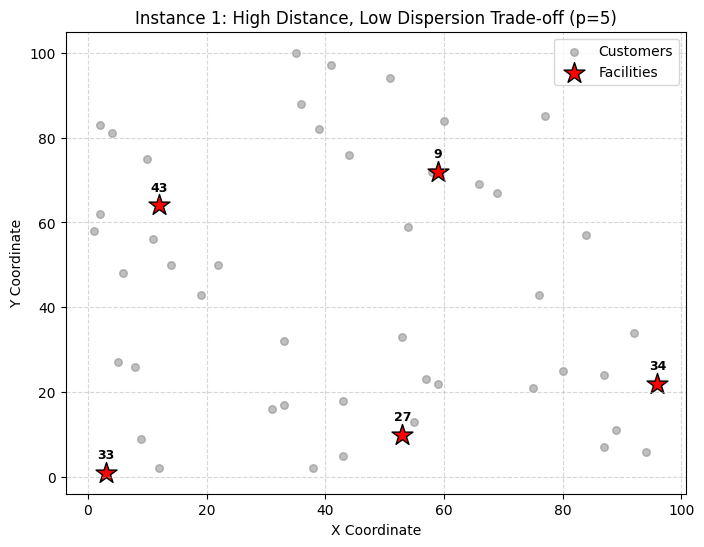

In [79]:
def plot_geographic_solution(instance, chromosome, title="Facility Locations"):
    """
    Plots the customer nodes and highlights the chosen facility locations.
    """
    # Extract coordinates for all customers
    all_x = [c['x'] for c in instance.customers]
    all_y = [c['y'] for c in instance.customers]
    
    # Extract coordinates for just the chosen facilities
    fac_x = [instance.customers[i]['x'] for i in chromosome]
    fac_y = [instance.customers[i]['y'] for i in chromosome]
    
    plt.figure(figsize=(8, 6))
    
    # Plot all customers as small gray dots
    plt.scatter(all_x, all_y, c='gray', label='Customers', alpha=0.5, s=30)
    
    # Plot facilities as large red stars
    plt.scatter(fac_x, fac_y, c='red', label='Facilities', marker='*', s=250, edgecolor='black')
    
    plt.title(f"Instance {instance.id}: {title} (p={instance.p})")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Optional: Annotate the facility IDs to see exactly which ones were chosen
    for i in chromosome:
        plt.annotate(str(i), (instance.customers[i]['x'], instance.customers[i]['y']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')
                     
    plt.show()

# Example usage (assuming pareto_chromosomes is the output from our run_nsga2 function):
# Pick one solution from the Pareto front, for example, the first one
plot_geographic_solution(parsed_instances[0], pareto_chromosomes[0], "High Distance, Low Dispersion Trade-off")

The Pareto Front
The closer the dots are to the diagonal (middle), the better the trade off

Generation 1/50 complete. Pareto Front 1 size: 4
Generation 2/50 complete. Pareto Front 1 size: 2
Generation 3/50 complete. Pareto Front 1 size: 2
Generation 4/50 complete. Pareto Front 1 size: 5
Generation 5/50 complete. Pareto Front 1 size: 8
Generation 6/50 complete. Pareto Front 1 size: 11
Generation 7/50 complete. Pareto Front 1 size: 15
Generation 8/50 complete. Pareto Front 1 size: 9
Generation 9/50 complete. Pareto Front 1 size: 9
Generation 10/50 complete. Pareto Front 1 size: 9
Generation 11/50 complete. Pareto Front 1 size: 16
Generation 12/50 complete. Pareto Front 1 size: 20
Generation 13/50 complete. Pareto Front 1 size: 55
Generation 14/50 complete. Pareto Front 1 size: 115
Generation 15/50 complete. Pareto Front 1 size: 186
Generation 16/50 complete. Pareto Front 1 size: 180
Generation 17/50 complete. Pareto Front 1 size: 185
Generation 18/50 complete. Pareto Front 1 size: 184
Generation 19/50 complete. Pareto Front 1 size: 180
Generation 20/50 complete. Pareto Front 1 

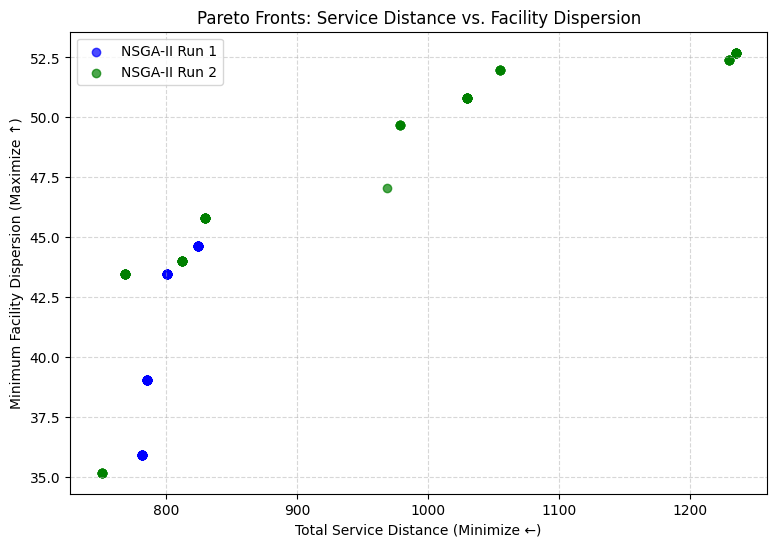

In [80]:
def plot_pareto_fronts(list_of_fitness_sets, run_labels):
    """
    Plots one or more Pareto fronts in the objective space.
    list_of_fitness_sets: A list containing lists of fitness tuples. 
                          e.g., [run1_fitnesses, run2_fitnesses]
    run_labels: A list of strings naming each run.
    """
    plt.figure(figsize=(9, 6))
    colors = ['blue', 'green', 'orange', 'purple', 'red']
    
    for i, fitnesses in enumerate(list_of_fitness_sets):
        # Extract Objective 1 (Service Distance)
        distances = [fit[0] for fit in fitnesses]
        
        # Extract Objective 2 and flip it back to positive (Dispersion)
        dispersions = [-fit[1] for fit in fitnesses]
        
        plt.scatter(distances, dispersions, label=run_labels[i], color=colors[i % len(colors)], alpha=0.7)
        
    plt.title("Pareto Fronts: Service Distance vs. Facility Dispersion")
    plt.xlabel("Total Service Distance (Minimize \u2190)") # Left arrow indicates direction of improvement
    plt.ylabel("Minimum Facility Dispersion (Maximize \u2191)") # Up arrow indicates direction of improvement
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Example usage:
# Let's say you ran NSGA-II twice to see if it converges consistently:
run1_chroms, run1_fits = run_nsga2(parsed_instances[0])
run2_chroms, run2_fits = run_nsga2(parsed_instances[0])
plot_pareto_fronts([run1_fits, run2_fits], ["NSGA-II Run 1", "NSGA-II Run 2"])

### Calculate the Hypervolume
Compare optimality between solutions

In [81]:
def calculate_2d_hypervolume(pareto_fitnesses, ref_point):
    """
    Calculates the 2D Hypervolume of a Pareto front.
    pareto_fitnesses: List of fitness tuples [(dist1, disp1), (dist2, disp2), ...]
    ref_point: A tuple representing the worst acceptable objective values (max_dist, max_disp).
    """
    if not pareto_fitnesses:
        return 0.0
        
    # Sort the front strictly by the first objective (Service Distance)
    sorted_front = sorted(pareto_fitnesses, key=lambda x: x[0])
    
    volume = 0.0
    # The 'height' boundary starts at the reference point's y-value
    current_y_bound = ref_point[1]
    
    for fitness in sorted_front:
        # Check if the point is actually better than the reference point
        if fitness[0] > ref_point[0] or fitness[1] > ref_point[1]:
            continue
            
        # Area of the rectangle formed by this point
        width = ref_point[0] - fitness[0]
        height = current_y_bound - fitness[1]
        
        volume += width * height
        
        # Update the boundary for the next rectangle
        current_y_bound = fitness[1]
        
    return volume

### Grid search
Test different paramters

Starting Grid Search: 4 combinations, 5 runs each.
Total algorithm executions: 20

Configuration 1/4 | {'pop_size': 100, 'generations': 60, 'crossover_rate': 0.8, 'mutation_rate': 0.2}
Generation 1/60 complete. Pareto Front 1 size: 3
Generation 2/60 complete. Pareto Front 1 size: 4
Generation 3/60 complete. Pareto Front 1 size: 5
Generation 4/60 complete. Pareto Front 1 size: 9
Generation 5/60 complete. Pareto Front 1 size: 9
Generation 6/60 complete. Pareto Front 1 size: 12
Generation 7/60 complete. Pareto Front 1 size: 6
Generation 8/60 complete. Pareto Front 1 size: 9
Generation 9/60 complete. Pareto Front 1 size: 7
Generation 10/60 complete. Pareto Front 1 size: 7
Generation 11/60 complete. Pareto Front 1 size: 10
Generation 12/60 complete. Pareto Front 1 size: 12
Generation 13/60 complete. Pareto Front 1 size: 12
Generation 14/60 complete. Pareto Front 1 size: 13
Generation 15/60 complete. Pareto Front 1 size: 29
Generation 16/60 complete. Pareto Front 1 size: 33
Generation 17/60 

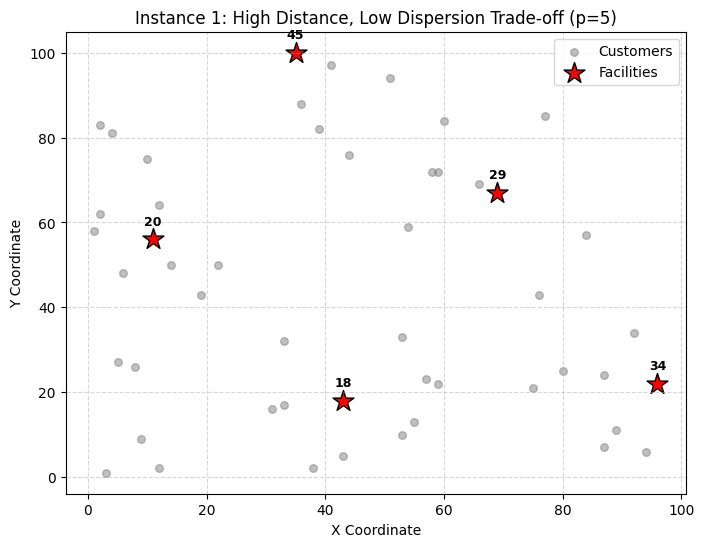

Hypervolume: 437717.2409298837


In [86]:
def grid_search_nsga2(instance, num_runs=5):
    """
    Runs a grid search over specified NSGA-II parameters.
    Evaluates each parameter combination 'num_runs' times and averages the Hypervolume.
    """
    param_grid = {
        'pop_size': [100, 200],
        'generations': [60, 120],
        'crossover_rate': [0.8],
        'mutation_rate': [0.2]
    }
    
    keys = param_grid.keys()
    combinations = list(itertools.product(*param_grid.values()))
    
    print(f"Starting Grid Search: {len(combinations)} combinations, {num_runs} runs each.")
    print(f"Total algorithm executions: {len(combinations) * num_runs}\n")
    
    # Reference point for Hypervolume 
    # (Must be worse than any possible solution in both objectives)
    ref_point = (10000.0, 0.0) 
    
    best_avg_hv = -1
    best_params = None
    best_overall_front = None
    
    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"Configuration {i+1}/{len(combinations)} | {params}")
        
        current_combo_hvs = []
        best_front_this_combo = None
        best_hv_this_combo = -1
        
        # Execute the algorithm multiple times for these exact parameters
        for run_idx in range(num_runs):
            _, fitnesses = run_nsga2(
                instance, 
                pop_size=params['pop_size'], 
                generations=params['generations'],
                crossover_rate=params['crossover_rate'],
                mutation_rate=params['mutation_rate']
            )
            
            hv = calculate_2d_hypervolume(fitnesses, ref_point)
            current_combo_hvs.append(hv)
            
            # Keep the physical front from the absolute best individual run 
            # within this parameter set, so we have it to return later
            if hv > best_hv_this_combo:
                best_hv_this_combo = hv
                best_front_this_combo = fitnesses
                
        # Calculate the average performance
        avg_hv = sum(current_combo_hvs) / num_runs
        min_hv = min(current_combo_hvs)
        max_hv = max(current_combo_hvs)
        
        print(f" -> Avg HV: {avg_hv:,.2f}  |  Min: {min_hv:,.0f}  |  Max: {max_hv:,.0f}\n")
        
        # Update the overall global best if this average beats the previous best average
        if avg_hv > best_avg_hv:
            best_avg_hv = avg_hv
            best_params = params
            best_overall_front = best_front_this_combo
            
    print("-" * 40)
    print("GRID SEARCH COMPLETE")
    print(f"Best Average Hypervolume: {best_avg_hv:,.2f}")
    print(f"Best Parameters: {best_params}")
    
    return best_params, best_overall_front

# Example usage:
best_parameters, best_pareto_front = grid_search_nsga2(parsed_instances[0])
pop_size, generations, crossover_rate, mutation_rate = best_parameters['pop_size'], best_parameters['generations'], best_parameters['crossover_rate'], best_parameters['mutation_rate']
pareto_chromosomes, pareto_fits = run_nsga2(parsed_instances[0], pop_size=pop_size, generations=generations, crossover_rate=crossover_rate, mutation_rate=mutation_rate)
plot_geographic_solution(parsed_instances[0], pareto_chromosomes[0], "High Distance, Low Dispersion Trade-off")
print(f"Hypervolume: {calculate_2d_hypervolume(pareto_fits, (10000.0, 0.0))}")